#Import Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16

In [ ]:
train_path = "/content/drive/MyDrive/MRI Detection/dataset/Training"
test_path  = "/content/drive/MyDrive/MRI Detection/dataset/Testing"

#LOAD DATASET

In [ ]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    class_names=class_names
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=False,
    class_names=class_names
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


#NORMALIZE

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
test_data  = test_data.map(lambda x, y: (normalization_layer(x), y))

#DATA AUGMENTATION

In [ ]:
# data_augmentation = tf.keras.Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.15),
#     layers.RandomZoom(0.1),
# ])

#Custom Focal Loss

In [ ]:
def focal_loss(gamma=2., alpha=.25):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=4)
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return loss

#LOAD EFFICIENTNETB0

In [ ]:
base_model = VGG16(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

#FINE TUNE

In [ ]:
for layer in base_model.layers[:-4]:
    layer.trainable = False

#BUILD MODEL

In [ ]:
x = base_model.output
x = layers.Flatten()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.6)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

#COMPILE

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#SMART CALLBACKS

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [ ]:
class_weights = {
    0: 1.5,   # glioma boosted
    1: 1.0,
    2: 1.0,
    3: 1.0
}

#TRAIN

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 53s 258ms/step - accuracy: 0.9406 - loss: 0.2134 - val_accuracy: 0.9044 - val_loss: 0.4499
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 244ms/step - accuracy: 0.9539 - loss: 0.1591 - val_accuracy: 0.8875 - val_loss: 0.4952
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 44s 253ms/step - accuracy: 0.9689 - loss: 0.1119 - val_accuracy: 0.9150 - val_loss: 0.4515


In [ ]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - accuracy: 0.8242 - loss: 0.9209
Test Accuracy: 0.9043750166893005


In [ ]:
model.save("brain_tumor_model.keras")

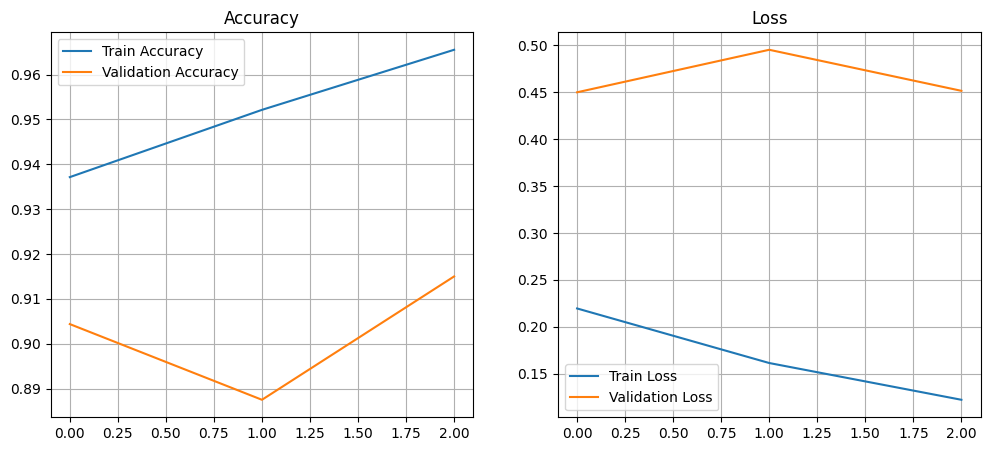

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.grid()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

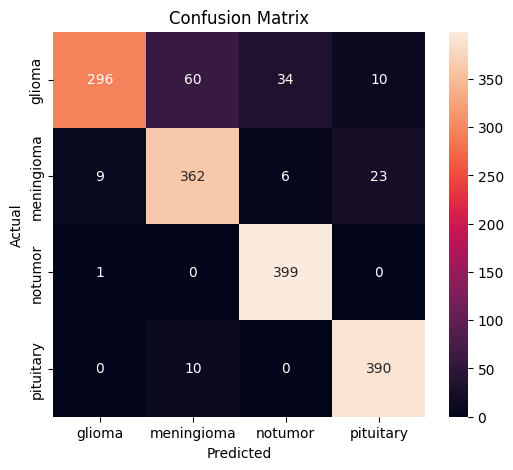

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.98      0.73      0.84       400
  meningioma       0.80      0.96      0.87       400
     notumor       0.93      0.99      0.96       400
   pituitary       0.98      0.97      0.97       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600

